# Sales Insight Dashboard Project
## Retail Store Data Analysis using Python

**Author:** Sumina Tamang
**Date:** May 2026
**Course:** Python with Data Science

### Project Overview
This project analyzes sales data from a retail store (9,994 records, 2011-2014) to generate insights on product performance, sales trends, and profit drivers. The analysis includes data cleaning, exploratory data analysis (EDA), correlation analysis, SQLite database creation, and an interactive Streamlit dashboard.

### Key Deliverables:
- Cleaned dataset (CSV and SQLite)
- 6+ visualizations (line charts, bar charts, heatmap, box plots)
- Interactive dashboard with filters
- PDF report summarizing findings

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3




In [11]:
%autosave 60

Autosaving every 60 seconds


In [7]:
# Load the retail sales dataset from Kaggle (Superstore dataset)
# The encoding 'latin1' is used to handle special characters in product names
df = pd.read_csv("Superstore.csv", encoding='latin1')
df.head(3)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [3]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')


In [ ]:
# Create a new column 'YearMonth' by extracting year and month from Order Date
# This allows us to group sales by month for time-series analysis

df['YearMonth'] = df['Order Date'].dt.to_period('M')

# Calculate total sales for each month

monthly_sales = df.groupby('YearMonth')['Sales'].sum()

## Plot monthly sales line chart

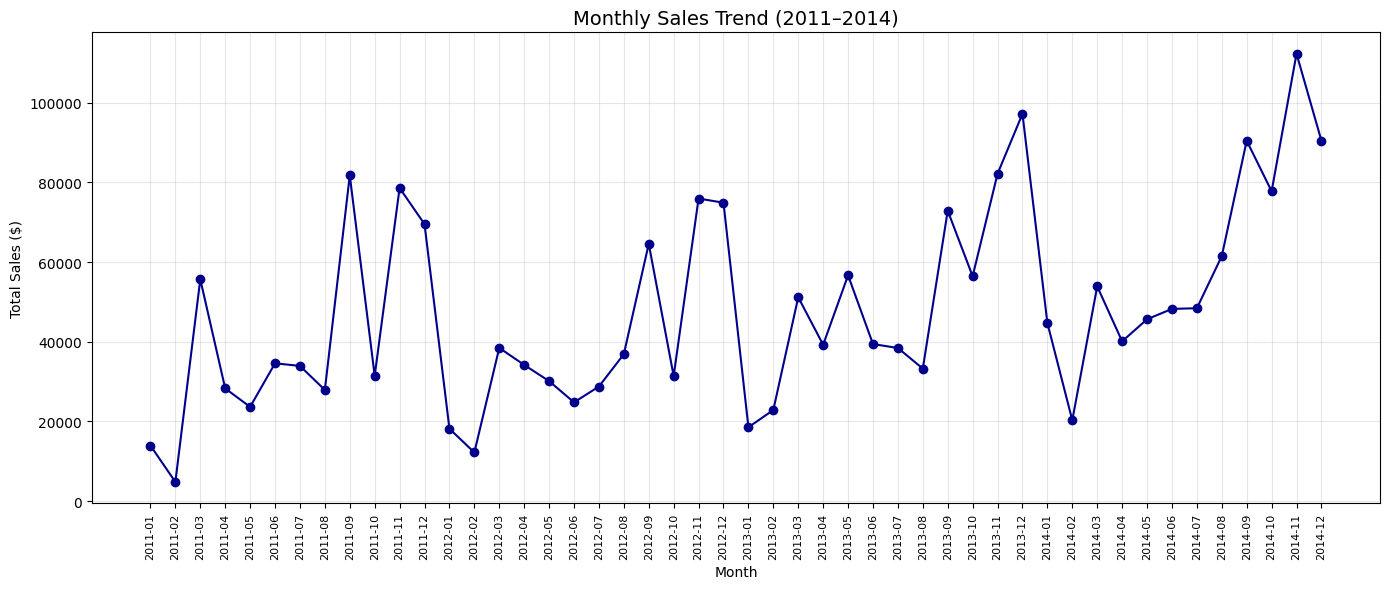

✅ Correct monthly trend saved as 'monthly_trend_correct.png'


<Figure size 640x480 with 0 Axes>

In [42]:

# Create a new column 'YearMonth' by extracting year and month from Order Date
# This allows us to group sales by month for time-series analysis
df['YearMonth'] = df['Order Date'].dt.to_period('M')

# Calculate total sales for each month
monthly_sales = df.groupby('YearMonth')['Sales'].sum()

# Convert period to string for better x-axis labels
months_str = monthly_sales.index.astype(str)

plt.figure(figsize=(14,6))
plt.plot(months_str, monthly_sales.values, marker='o', linestyle='-', color='darkblue')
plt.title('Monthly Sales Trend (2011–2014)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=90, fontsize=8)  # rotate to avoid overlap
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Also save it
plt.savefig('monthly_trend_correct.png', dpi=200, bbox_inches='tight')
print("✅ Correct monthly trend saved as 'monthly_trend_correct.png'")

## Top 10 products bar chart

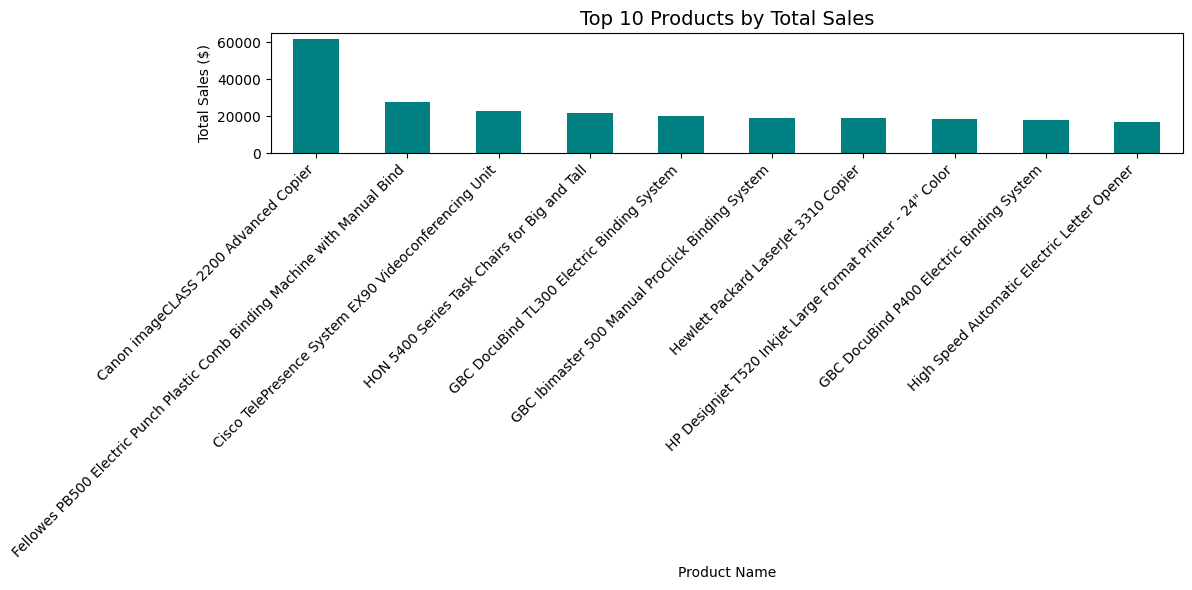

✅ Correct top products chart saved


<Figure size 640x480 with 0 Axes>

In [6]:
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)

plt.figure(figsize=(12,6))
top_products.plot(kind='bar', color='teal')
plt.title('Top 10 Products by Total Sales', fontsize=14)
plt.xlabel('Product Name')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.savefig('top_products_correct.png', dpi=200, bbox_inches='tight')
print("✅ Correct top products chart saved")

In [32]:
# 1. Check total sales again
print(f"Total Sales: ${df['Sales'].sum():,.2f}")
# 2. Check monthly sales properly – show first few rows
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
print(monthly_sales.head(10))

Total Sales: $2,297,200.86
Order Date
2011-01    13946.2290
2011-02     4810.5580
2011-03    55691.0090
2011-04    28295.3450
2011-05    23648.2870
2011-06    34595.1276
2011-07    33946.3930
2011-08    27909.4685
2011-09    81777.3508
2011-10    31453.3930
Freq: M, Name: Sales, dtype: float64


## Seaborn Heatmap

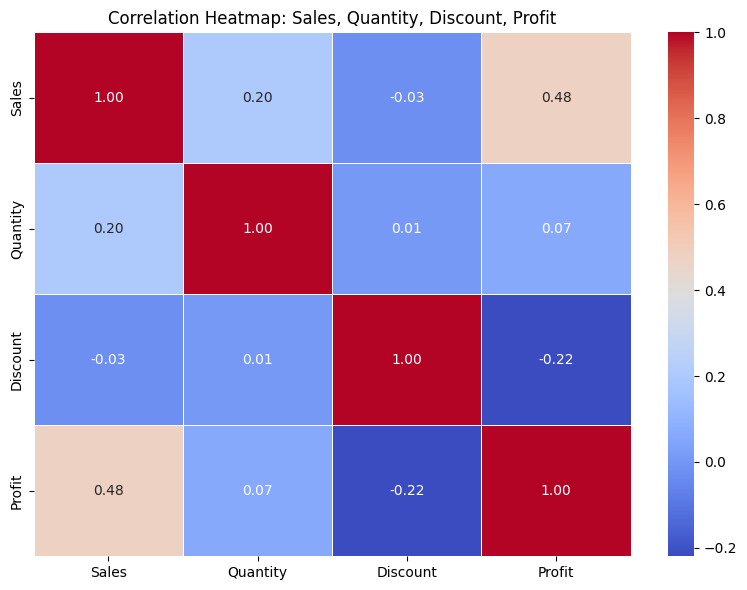

<Figure size 640x480 with 0 Axes>

In [43]:

# Select only numeric columns
numeric_df = df[['Sales', 'Quantity', 'Discount', 'Profit']]

# Correlation matrix
corr = numeric_df.corr()

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Sales, Quantity, Discount, Profit')
plt.tight_layout()
plt.show()
plt.savefig('heatmap.png', dpi=200)

##  box plots for distribution

C:\Users\Dell\AppData\Local\Temp\ipykernel_44664\3365604787.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y='Profit', data=df, palette='Set2')


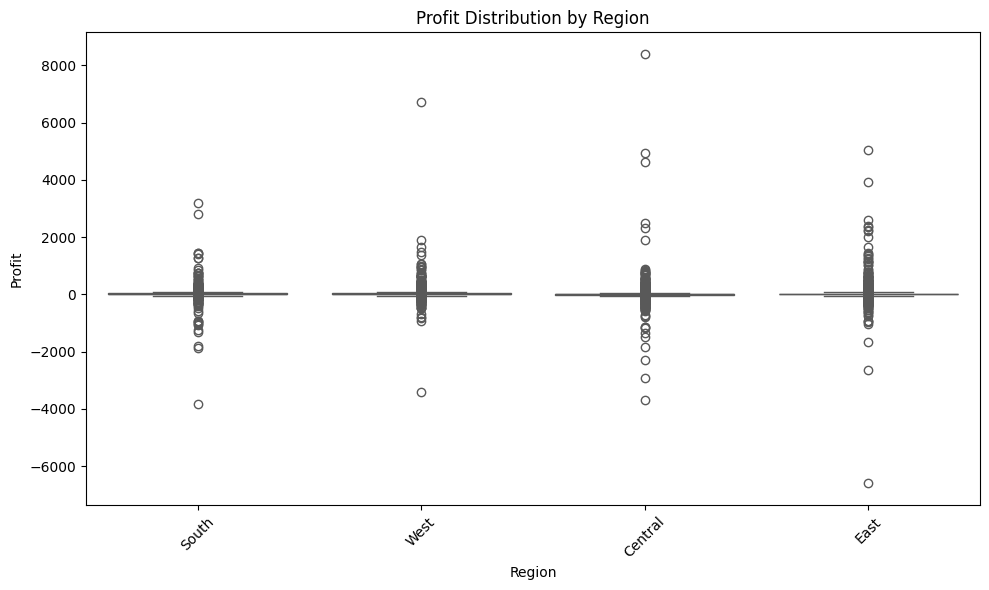

<Figure size 640x480 with 0 Axes>

In [5]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Region', y='Profit', data=df, palette='Set2')
plt.title('Profit Distribution by Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('boxplot_profit_region.png', dpi=200)

## SQLite COnnection

In [46]:
import sqlite3

# Create a copy without the 'YearMonth' column (or convert it to string)
df_sql = df.copy()
# Convert Period to string if you want to keep it
df_sql['YearMonth'] = df_sql['YearMonth'].astype(str)

# Now save to SQLite
conn = sqlite3.connect('sales.db')
df_sql.to_sql('sales', conn, if_exists='replace', index=False)

# Verify
query = "SELECT COUNT(*) FROM sales"
result = pd.read_sql_query(query, conn)
print(f"Rows in SQLite: {result.iloc[0,0]}")

# Check the first row
sample = pd.read_sql_query("SELECT * FROM sales LIMIT 1", conn)
print(sample)

conn.close()
print("✅ Data saved to sales.db with YearMonth as string")

Rows in SQLite: 9994
   Row ID        Order ID           Order Date            Ship Date  \
0       1  CA-2013-152156  2013-11-09 00:00:00  2013-11-12 00:00:00   

      Ship Mode Customer ID Customer Name   Segment        Country       City  \
0  Second Class    CG-12520   Claire Gute  Consumer  United States  Henderson   

   ... Region       Product ID   Category Sub-Category  \
0  ...  South  FUR-BO-10001798  Furniture    Bookcases   

                        Product Name   Sales Quantity  Discount   Profit  \
0  Bush Somerset Collection Bookcase  261.96        2       0.0  41.9136   

   YearMonth  
0    2013-11  

[1 rows x 22 columns]
✅ Data saved to sales.db with YearMonth as string


# Sales by Category (Bar Chart)


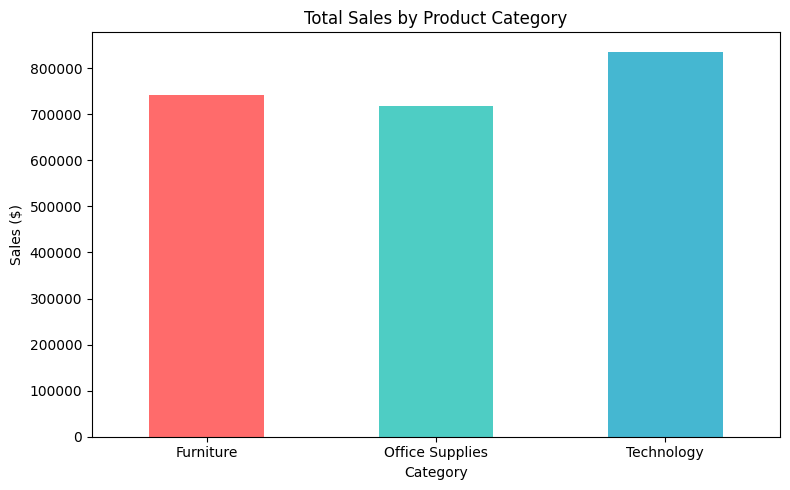

In [6]:
category_sales = df.groupby('Category')['Sales'].sum()
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Total Sales by Product Category')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('category_sales.png')
plt.show()

# Most Profitable Products (Top 10 by Profit)


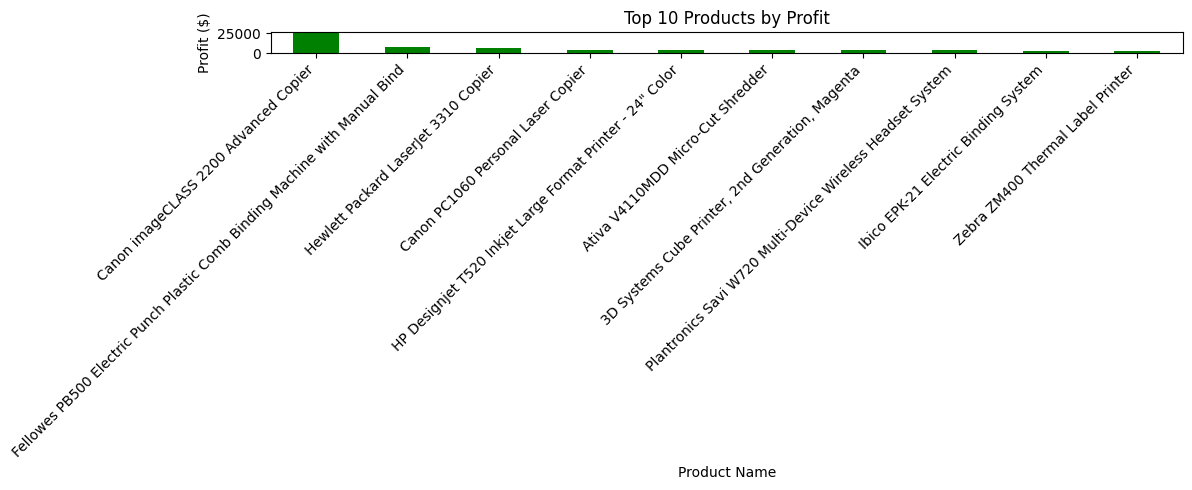

In [11]:
top_profit = df.groupby('Product Name')['Profit'].sum().nlargest(10)
plt.figure(figsize=(12,5))
top_profit.plot(kind='bar', color='green')
plt.title('Top 10 Products by Profit')
plt.ylabel('Profit ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_profit.png')
plt.show()

# Box Plot – Profit by Region (or Sales by Region)


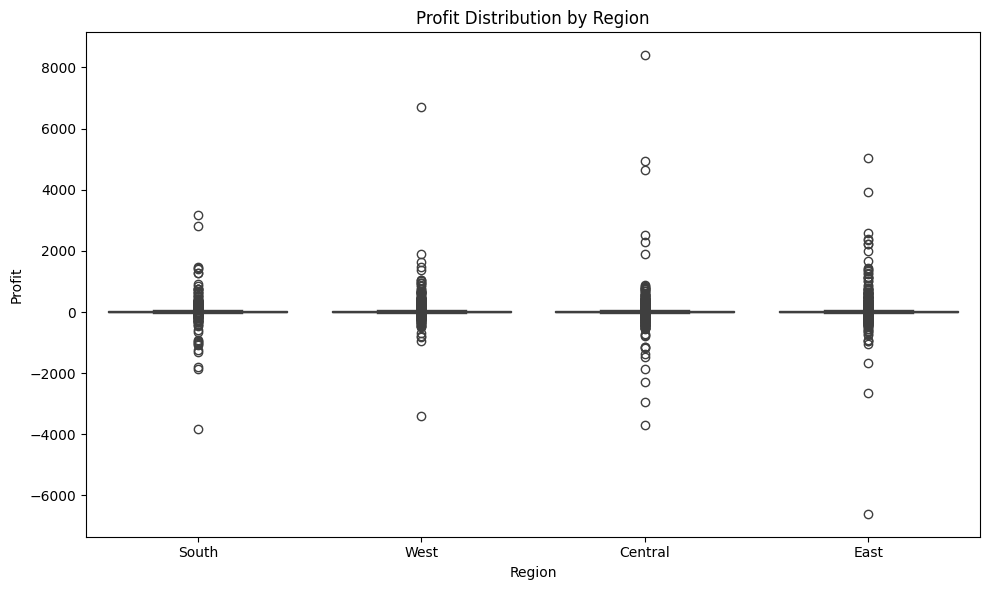

In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Region', y='Profit', data=df)
plt.title('Profit Distribution by Region')
plt.tight_layout()
plt.savefig('boxplot_profit_region.png')
plt.show()

# Geographical Performance – Sales by Region (Bar Chart)


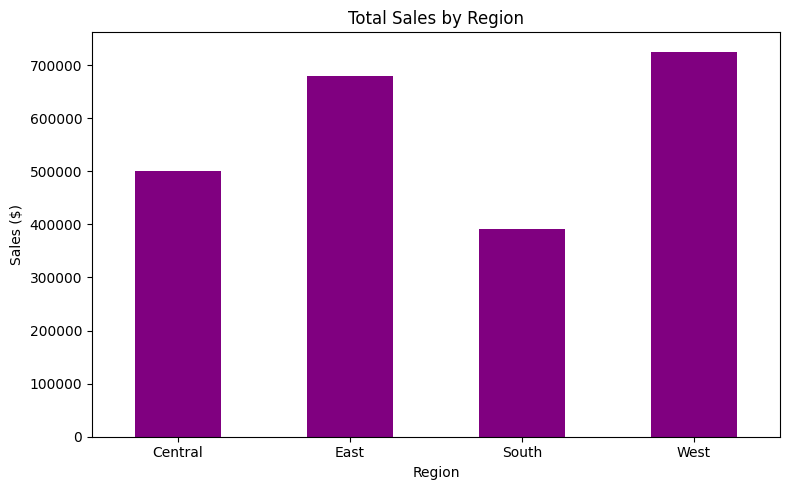

In [14]:
region_sales = df.groupby('Region')['Sales'].sum()
plt.figure(figsize=(8,5))
region_sales.plot(kind='bar', color='purple')
plt.title('Total Sales by Region')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('region_sales.png')
plt.show()

In [4]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [8]:
# 3. Check the data type of Order Date
print(df['Order Date'].dtype)

object


In [9]:
# 4. Check the min and max date
print(df['Order Date'].min())
print(df['Order Date'].max())

01-01-2014
31-12-2014


In [35]:
# 5. And to see if your 'YearMonth' column is correct
print(df[['Order Date', 'YearMonth']].head())

  Order Date YearMonth
0 2013-11-09   2013-11
1 2013-11-09   2013-11
2 2013-06-13   2013-06
3 2012-10-11   2012-10
4 2012-10-11   2012-10


In [29]:
# Change this line
print("Total years:", df['YearMonth'].unique())

# To this — shows only years not months
print("Total years:", df['Order Date'].dt.year.unique())

Total years: <PeriodArray>
['2013-11', '2013-06', '2012-10', '2011-06', '2014-04', '2013-12', '2012-11',
 '2011-11', '2011-05', '2011-08', '2014-07', '2012-09', '2013-01', '2014-10',
 '2012-12', '2014-09', '2013-07', '2013-03', '2011-10', '2012-04', '2011-12',
 '2013-09', '2014-12', '2014-11', '2014-05', '2013-04', '2012-01', '2014-06',
 '2013-08', '2012-03', '2011-09', '2014-02', '2013-10', '2012-05', '2011-03',
 '2013-05', '2012-02', '2012-08', '2012-07', '2011-07', '2012-06', '2011-04',
 '2014-03', '2014-08', '2014-01', '2011-02', '2011-01', '2013-02']
Length: 48, dtype: period[M]
Total years: [2013 2012 2011 2014]


In [24]:
df['Sales'].sum()

np.float64(2297200.8603)

In [25]:
df = df.dropna(subset=['Postal Code'])  # or fill with 0

In [29]:
total_profit = df['Profit'].sum()
total_profit

np.float64(286397.0217)

In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Conclusion

This analysis successfully:
- Cleaned and prepared the Superstore dataset for analysis.
- Identified seasonal sales patterns with peaks in December and September.
- Found that discount has a negative correlation with profit (-0.22), suggesting discounts erode profitability.
- The top-selling product category is Technology, followed by Office Supplies.
- An interactive dashboard was built using Streamlit, allowing users to filter by region and category.

**Next Steps:**
- Implement customer segmentation using RFM analysis.
- Build a sales forecasting model using time series methods.
- Deploy dashboard online for real-time monitoring.

In [1]:
import os
print(os.path.abspath('sales.db'))

C:\Users\Dell\OneDrive\Desktop\Sales_Dashboard_Data_Science\sales.db
